# FingerPrint-Based Multi-Layer Perceptron

In [22]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import pandas as pd
import numpy as np
from pyprojroot import here
import joblib
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import Ridge
from sklearn.kernel_ridge import KernelRidge as KR
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from dl_hplc_smrt.data_transformers import SmilesToMolTransformer as STM
from dl_hplc_smrt.data_transformers import MolToFingerPrintTransformer as MTFP
from dl_hplc_smrt.models import ComplexMultilayerPerceptron as CMLP
from dl_hplc_smrt.utils import OptimizeParametersValidation as OPV
from dl_hplc_smrt.utils import evaluate_sklearn_model, plot_results

In [24]:
sns.set_style("whitegrid")

In [25]:
RAW_DATA_PATH = here() / "data" / "raw"
PROCESSED_DATA_PATH = here() / "data" / "processed"

### Read the SMILES Sets (Train, Validation, Test)

In [26]:
x_train_ret = np.load(PROCESSED_DATA_PATH / "X_train_set_retained.npy", allow_pickle=True).reshape(-1,1)
x_val_ret = np.load(PROCESSED_DATA_PATH / "X_val_set_retained.npy", allow_pickle=True).reshape(-1,1)
x_test_ret = np.load(PROCESSED_DATA_PATH / "X_test_set_retained.npy", allow_pickle=True).reshape(-1,1)
print(x_train_ret.shape, x_val_ret.shape, x_test_ret.shape)
x_train_ret[0:5,:]


(59593, 1) (6623, 1) (10710, 1)


array([['COc1ccc(CC(O)=NC2CCN(c3nnc4ccccn34)CC2)cc1'],
       ['CCc1noc(N=C(C)O)c1-c1ccc(OC)c(S(=O)(=O)N2CC=C(c3ccccc3)CC2)c1'],
       ['CN(C)CCCN=C(O)C1CCN(c2nc3ccc(-c4cccnc4)nc3s2)CC1'],
       ['CCOC(=O)c1c(S(=O)(=O)N2CCc3ccccc3C2)c(C)n(C)c1C'],
       ['Cc1cc(C)c(N=C(O)Cn2cnc3nc(N4CCC(C(O)=NC5CC5)CC4)sc3c2=O)c(C)c1']],
      dtype=object)

In [27]:
y_train_ret = np.load(PROCESSED_DATA_PATH / "y_train_set_retained.npy", allow_pickle=True)
y_val_ret = np.load(PROCESSED_DATA_PATH / "y_val_set_retained.npy", allow_pickle=True)
y_test_ret = np.load(PROCESSED_DATA_PATH / "y_test_set_retained.npy", allow_pickle=True)
print(y_train_ret.shape, y_val_ret.shape, y_test_ret.shape)
y_train_ret[0:5]

(59593,) (6623,) (10710,)


array([626.4, 917.6, 543.4, 989.2, 754.4])

#### Convert SMILES to mol

In [ ]:
print(x_train_ret.shape)
fp_transformer = STM().fit(x_train_ret)
x_train_ret_processed = fp_transformer.transform(x_train_ret)
print(x_train_ret_processed.shape)

(59593, 1)
(59593, 1)


#### Convert to fingerprints (Morgan, for example)

In [ ]:
print(x_train_ret_processed.shape)
fp_transformer = MTFP(fp_type="morgan", radius=5, fp_size=1024, dense=True, counts=True).fit(x_train_ret_processed)
x_train_ret_processed = fp_transformer.transform(x_train_ret_processed)
print(x_train_ret_processed.shape)

(59593, 1)
(59593, 1024)


#### Normalize the variance

In [30]:
print(x_train_ret_processed.shape)
standard_scaler = StandardScaler(with_mean=True).fit(x_train_ret_processed)
x_train_ret_processed = standard_scaler.transform(x_train_ret_processed)
print(x_train_ret_processed.shape)

(59593, 1024)
(59593, 1024)


#### Filter by variance (let's remove those that are always zero or very unusual)

In [31]:
print(x_train_ret_processed.shape)
variance_thres = VarianceThreshold(threshold=0.0).fit(x_train_ret_processed)
x_train_ret_processed = variance_thres.transform(x_train_ret_processed)
print(x_train_ret_processed.shape)

(59593, 1024)
(59593, 1024)


In [32]:
x_train_ret_processed[:5,:5]

array([[-0.2147815 , -0.45340656, -0.3312962 ,  3.09786684, -0.54274712],
       [-0.2147815 , -0.45340656, -0.3312962 , -0.28087689, -0.54274712],
       [-0.2147815 ,  1.75500025, -0.3312962 , -0.28087689, -0.54274712],
       [-0.2147815 , -0.45340656, -0.3312962 , -0.28087689, -0.54274712],
       [-0.2147815 , -0.45340656, -0.3312962 , -0.28087689, -0.54274712]])

### First Tests: Morgan Fingerprints Based on Bits 

Let's Write a Data Processing Pipleline

In [ ]:
fp_based_preparation = Pipeline([
    ("mol_converter", STM()),
    ("fp_transformer", MTFP(fp_type="morgan", radius=2, fp_size=1024, dense=True, counts=False)),
    ("standard_scaler", StandardScaler(with_mean=False)),
    ("variance_thres", VarianceThreshold(threshold=0.0)),# Remove constant all-zero features    
    ])

In [34]:
x_train_ret_processed = fp_based_preparation.fit_transform(x_train_ret)
x_val_ret_processed = fp_based_preparation.transform(x_val_ret)
x_test_ret_processed = fp_based_preparation.transform(x_test_ret)

In [35]:
print(x_train_ret_processed.shape)
print(x_val_ret_processed.shape)
print(x_test_ret_processed.shape)

(59593, 1024)
(6623, 1024)
(10710, 1024)


# Comparing Different Fingerprints and Models

We will use these scores

In [36]:
scores={
    "r**2": r2_score,
    "mae": mean_absolute_error,
    "mse": mean_squared_error,
    "rmse": root_mean_squared_error
}

### MACCS Bits

Change the parameters of the data transformation pipeline

In [37]:
new_params = {
    "fp_transformer__fp_type": "maccs",
    "fp_transformer__counts": False
}
fp_based_preparation.set_params(**new_params)

x_train_ret_processed = fp_based_preparation.fit_transform(x_train_ret)
x_val_ret_processed = fp_based_preparation.transform(x_val_ret)
x_test_ret_processed = fp_based_preparation.transform(x_test_ret)

print(x_train_ret_processed.shape)
print(x_val_ret_processed.shape)
print(x_test_ret_processed.shape)

(59593, 152)
(6623, 152)
(10710, 152)


In [38]:
datasets={
    "train": [x_train_ret_processed, y_train_ret],
    "validation": [x_val_ret_processed, y_val_ret]
}

Ridge regression model

In [39]:
ridge_model = Ridge(alpha=1)
ridge_model.fit(X=x_train_ret_processed, y=y_train_ret)
evaluate_sklearn_model(model=ridge_model, datasets=datasets, scores=scores)

,dataset,r**2,mae,mse,rmse
0,train,0.405104,104.938432,18203.918873,134.921899
1,validation,0.396676,105.136378,18452.572310,135.840246


Random Forest model

In [40]:
rfr_model = RFR(n_estimators=300, max_depth=25, max_features=0.7, max_samples=0.7, n_jobs=6)
rfr_model.fit(X=x_train_ret_processed, y=y_train_ret)
evaluate_sklearn_model(model=rfr_model, datasets=datasets, scores=scores)

,dataset,r**2,mae,mse,rmse
0,train,0.905424,38.231967,2894.051452,53.796389
1,validation,0.680830,69.593392,9761.766415,98.801652


### Morgan Bits

In [41]:
new_params = {
    "fp_transformer__fp_type": "morgan",
    "fp_transformer__counts": False,
    "fp_transformer__fp_size": 1024,
    "fp_transformer__radius": 2

}
fp_based_preparation.set_params(**new_params)

x_train_ret_processed = fp_based_preparation.fit_transform(x_train_ret)
x_val_ret_processed = fp_based_preparation.transform(x_val_ret)
x_test_ret_processed = fp_based_preparation.transform(x_test_ret)

print(x_train_ret_processed.shape)
print(x_val_ret_processed.shape)
print(x_test_ret_processed.shape)

(59593, 1024)
(6623, 1024)
(10710, 1024)


In [42]:
datasets={
    "train": [x_train_ret_processed, y_train_ret],
    "validation": [x_val_ret_processed, y_val_ret]
}

Ridge regression model

In [43]:
ridge_model = Ridge(alpha=1)
ridge_model.fit(X=x_train_ret_processed, y=y_train_ret)
evaluate_sklearn_model(model=ridge_model, datasets=datasets, scores=scores)

,dataset,r**2,mae,mse,rmse
0,train,0.648713,76.800651,10749.440278,103.679508
1,validation,0.610897,79.695675,11900.646993,109.090087


Random Forest model

In [44]:
rfr_model = RFR(n_estimators=300, max_depth=25, max_features=0.7, max_samples=0.7, n_jobs=6)
rfr_model.fit(X=x_train_ret_processed, y=y_train_ret)
evaluate_sklearn_model(model=rfr_model, datasets=datasets, scores=scores)

,dataset,r**2,mae,mse,rmse
0,train,0.840370,52.770884,4884.702889,69.89065
1,validation,0.678769,71.770480,9824.782241,99.12004


### Morgan Counts

In [45]:
new_params = {
    "fp_transformer__fp_type": "morgan",
    "fp_transformer__counts": True,
    "fp_transformer__fp_size": 1024,
    "fp_transformer__radius": 2

}
fp_based_preparation.set_params(**new_params)

x_train_ret_processed = fp_based_preparation.fit_transform(x_train_ret)
x_val_ret_processed = fp_based_preparation.transform(x_val_ret)
x_test_ret_processed = fp_based_preparation.transform(x_test_ret)

print(x_train_ret_processed.shape)
print(x_val_ret_processed.shape)
print(x_test_ret_processed.shape)

(59593, 1024)
(6623, 1024)
(10710, 1024)


In [46]:
datasets={
    "train": [x_train_ret_processed, y_train_ret],
    "validation": [x_val_ret_processed, y_val_ret]
}

Ridge regression model

In [47]:
ridge_model = Ridge(alpha=1)
ridge_model.fit(X=x_train_ret_processed, y=y_train_ret)
evaluate_sklearn_model(model=ridge_model, datasets=datasets, scores=scores)

,dataset,r**2,mae,mse,rmse
0,train,0.695012,70.221251,9332.672410,96.605758
1,validation,0.666909,72.399478,10187.529962,100.933295


Random Forest model

In [48]:
rfr_model = RFR(n_estimators=300, max_depth=25, max_features=0.7, max_samples=0.7, n_jobs=6)
rfr_model.fit(X=x_train_ret_processed, y=y_train_ret)
evaluate_sklearn_model(model=rfr_model, datasets=datasets, scores=scores)

,dataset,r**2,mae,mse,rmse
0,train,0.869844,47.193675,3982.781097,63.109279
1,validation,0.701080,67.892182,9142.415900,95.615981


### RDKit Bits

In [49]:
new_params = {
    "fp_transformer__fp_type": "rdkit",
    "fp_transformer__counts": False,
    "fp_transformer__fp_size": 1024,
    "fp_transformer__radius": 5

}
fp_based_preparation.set_params(**new_params)

x_train_ret_processed = fp_based_preparation.fit_transform(x_train_ret)
x_val_ret_processed = fp_based_preparation.transform(x_val_ret)
x_test_ret_processed = fp_based_preparation.transform(x_test_ret)

print(x_train_ret_processed.shape)
print(x_val_ret_processed.shape)
print(x_test_ret_processed.shape)

(59593, 1024)
(6623, 1024)
(10710, 1024)


In [50]:
datasets={
    "train": [x_train_ret_processed, y_train_ret],
    "validation": [x_val_ret_processed, y_val_ret]
}

Ridge regression model

In [51]:
ridge_model = Ridge(alpha=1)
ridge_model.fit(X=x_train_ret_processed, y=y_train_ret)
evaluate_sklearn_model(model=ridge_model, datasets=datasets, scores=scores)

,dataset,r**2,mae,mse,rmse
0,train,0.623697,80.753421,11514.939872,107.307688
1,validation,0.592903,83.307531,12451.004246,111.584068


Random Forest model

In [52]:
rfr_model = RFR(n_estimators=300, max_depth=25, max_features=0.7, max_samples=0.7, n_jobs=6)
rfr_model.fit(X=x_train_ret_processed, y=y_train_ret)
evaluate_sklearn_model(model=rfr_model, datasets=datasets, scores=scores)

,dataset,r**2,mae,mse,rmse
0,train,0.929797,32.721304,2148.211587,46.348804
1,validation,0.735225,62.855071,8098.083808,89.989354


### RDKit Counts

In [53]:
new_params = {
    "fp_transformer__fp_type": "rdkit",
    "fp_transformer__counts": True,
    "fp_transformer__fp_size": 1024,
    "fp_transformer__radius": 5

}
fp_based_preparation.set_params(**new_params)

x_train_ret_processed = fp_based_preparation.fit_transform(x_train_ret)
x_val_ret_processed = fp_based_preparation.transform(x_val_ret)
x_test_ret_processed = fp_based_preparation.transform(x_test_ret)

print(x_train_ret_processed.shape)
print(x_val_ret_processed.shape)
print(x_test_ret_processed.shape)

(59593, 1024)
(6623, 1024)
(10710, 1024)


In [54]:
datasets={
    "train": [x_train_ret_processed, y_train_ret],
    "validation": [x_val_ret_processed, y_val_ret]
}

Ridge regression model

In [55]:
ridge_model = Ridge(alpha=1)
ridge_model.fit(X=x_train_ret_processed, y=y_train_ret)
evaluate_sklearn_model(model=ridge_model, datasets=datasets, scores=scores)

,dataset,r**2,mae,mse,rmse
0,train,0.740383,63.275662,7944.33353,89.130991
1,validation,0.726115,64.336905,8376.72364,91.524443


Random Forest model

In [56]:
rfr_model = RFR(n_estimators=300, max_depth=25, max_features=0.7, max_samples=0.7, n_jobs=6)
rfr_model.fit(X=x_train_ret_processed, y=y_train_ret)
evaluate_sklearn_model(model=rfr_model, datasets=datasets, scores=scores)

,dataset,r**2,mae,mse,rmse
0,train,0.935243,30.934559,1981.580195,44.514944
1,validation,0.767848,57.418227,7100.323347,84.263416


### Conclussions

1. For all fingerprints considered, there is model performance to be gain by using Random Forest instead of Ridge regression. Modeling the nonlionear behavior is important.
2. RdKit counts appear to be the best option to build our modeks based on fingerprints.
3. RF models appear to be strongly overfitted, it should be possible to improve them by include regularization, tuning the hyperparameters

## Base Model: Random Forest

So our baseline model will Random Forest based on RDKit counts. Let's try to get our best model by tuning the hyperparameters

Let's prepare a new pipeline including the model

In [ ]:
rfr_rdkit_pipeline = Pipeline([    
    ("mol_converter", STM()),
    ("fp_transformer", MTFP(fp_type="rdkit", radius=5, fp_size=1024, dense=True, counts=True)),
    ("standard_scaler", StandardScaler(with_mean=False)),
    ("variance_thres", VarianceThreshold(threshold=0.0)),# Remove constant all-zero features    
    ("rfr", RFR(n_jobs=6))
    ])

Let's do a first search with 0.70 of the data

In [58]:
x_temp_1, x_temp_2, y_temp_1, y_temp_2 = train_test_split(x_train_ret, y_train_ret, train_size=0.70)

First, let's tune the fp radius

In [59]:
rfr_param_grid = {
    'fp_transformer__radius': [1,3,5,7,9],
}
rfr_hyperparam_tuning = OPV(model=rfr_rdkit_pipeline, param_grid=rfr_param_grid, scoring=mean_absolute_error, keep_highest=False, keep_lowest=False).fit(x_temp_1, y_temp_1, x_val_ret, y_val_ret)
results = rfr_hyperparam_tuning.get_results()
results.sort_values(by = "validation score").head(10)

100%|██████████| 5/5 [19:13<00:00, 230.80s/it]


,fp_transformer__radius,train score,validation score
1,3,22.552174,58.495275
2,5,22.870749,59.701604
0,1,28.796904,66.012571
3,7,25.649751,67.367296
4,9,28.872080,75.980279


Three seems to be the sweet spot

First, let's tune max_features and max_samples together

In [60]:
rfr_param_grid = {
    'rfr__max_features': [0.25, 0.5, 0.7, 0.9],
    'rfr__max_samples': [0.25, 0.5, 0.7, 0.9],
}
rfr_rdkit_pipeline.set_params(**rfr_hyperparam_tuning.lowest_params_)
rfr_hyperparam_tuning = OPV(model=rfr_rdkit_pipeline, param_grid=rfr_param_grid, scoring=mean_absolute_error, keep_highest=False, keep_lowest=False).fit(x_temp_1, y_temp_1, x_val_ret, y_val_ret)
results = rfr_hyperparam_tuning.get_results()
results.sort_values(by = "validation score").head(10)

100%|██████████| 16/16 [14:06<00:00, 52.93s/it]


,rfr__max_features,rfr__max_samples,train score,validation score
3,0.25,0.9,24.830570,58.277807
7,0.50,0.9,24.781086,58.315436
11,0.70,0.9,24.836286,58.324061
15,0.90,0.9,24.834978,58.619483
2,0.25,0.7,30.516887,59.179170
6,0.50,0.7,30.497897,59.306271
10,0.70,0.7,30.507914,59.413810
14,0.90,0.7,30.561154,59.517762
13,0.90,0.5,38.070902,60.754309
1,0.25,0.5,38.144441,60.965800


Clearly, the most important factor is to set rfr__max_samples to 0.9. rfr__max_features will be set to 0.25

Now it is the turn of the max_depth

In [61]:
rfr_param_grid = {
    'rfr__max_depth': [5, 25, 50, 100, 200, None],
}
rfr_rdkit_pipeline.set_params(**rfr_hyperparam_tuning.lowest_params_)
rfr_hyperparam_tuning = OPV(model=rfr_rdkit_pipeline, param_grid=rfr_param_grid, scoring=mean_absolute_error, keep_highest=False, keep_lowest=False).fit(x_temp_1, y_temp_1, x_val_ret, y_val_ret)
results = rfr_hyperparam_tuning.get_results()
results.sort_values(by = "validation score").head(10)

100%|██████████| 6/6 [04:12<00:00, 42.12s/it]


,rfr__max_depth,train score,validation score
2,50.0,24.807438,58.164873
3,100.0,24.827488,58.279135
5,NaN,24.850505,58.321029
4,200.0,24.899862,58.400610
1,25.0,30.157874,59.267936
0,5.0,106.633777,107.025193


Very deep trees! 50 is selected as the best option

Let's modify our pipeline to include best parameters so far, work with the whole dataset and evaluate the current best model

In [ ]:
rfr_rdkit_pipeline = Pipeline([    
    ("mol_converter", STM()),
    ("fp_transformer", MTFP(fp_type="rdkit", radius=3, fp_size=1024, dense=True, counts=True)),
    ("standard_scaler", StandardScaler(with_mean=False)),
    ("variance_thres", VarianceThreshold(threshold=0.0)),# Remove constant all-zero features    
    ("rfr", RFR(n_estimators=300, max_depth=50, max_features=0.25, max_samples=0.9, n_jobs=7, random_state=123456))
    ])

rfr_rdkit_pipeline.fit(x_train_ret, y_train_ret)
datasets={
    "train": [x_train_ret, y_train_ret],
    "validation": [x_val_ret, y_val_ret]
}
evaluate_sklearn_model(model=rfr_rdkit_pipeline, datasets=datasets, scores=scores)

,dataset,r**2,mae,mse,rmse
0,train,0.959690,23.173600,1233.505052,35.121291
1,validation,0.780982,54.222969,6698.622871,81.845115


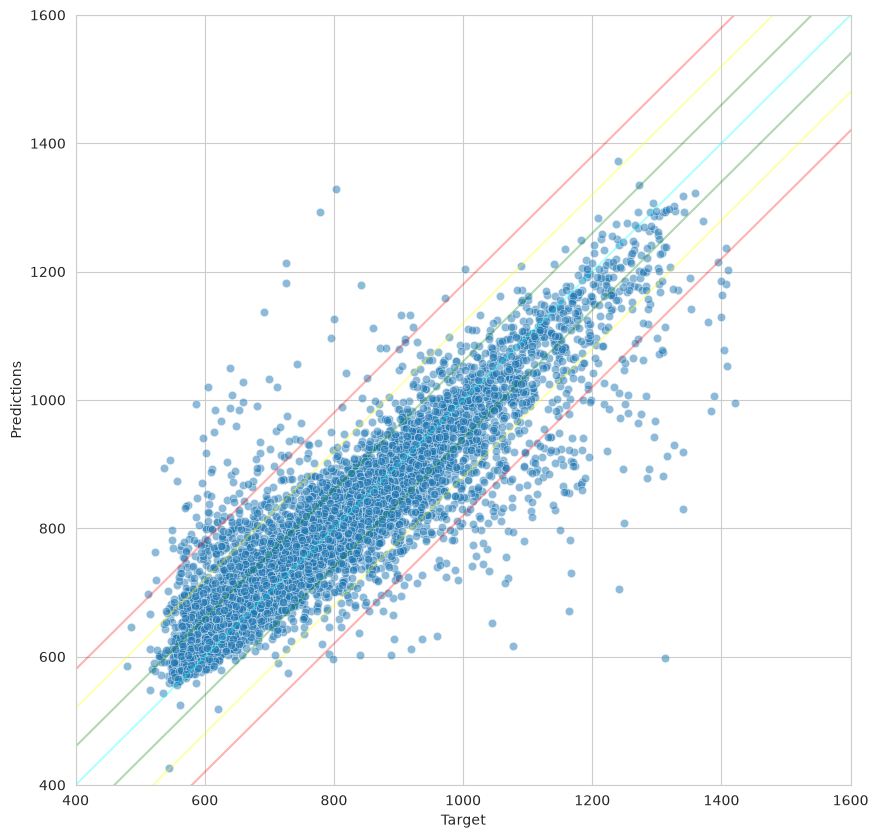

In [66]:
my_fig = plot_results(y_val_ret, rfr_rdkit_pipeline.predict(x_val_ret))

## Save Baseline Model

In [68]:
joblib.dump(rfr_rdkit_pipeline, here() / "models" / "random_forest" /"random_forest_rdkit_pipeline_2026_06_29_v0.pkl", compress=3)

['/home/adrian/PROJECTS/HPLC_RT_PRED/models/random_forest/random_forest_rdkit_pipeline_2026_06_29_v0.pkl']